# Training 5-Fold Spatial CV U-Net dan ProCANet

Notebook ini hanya orkestrasi eksekusi. Training, dataset loader, model, loss, metrik, checkpoint, early stopping, scheduler, gradient accumulation, AMP, spatial fold, dan opsi label water/river tetap memakai kode repo: `scripts/train_segmentation.py` dan modul `training/`.

Default target tetap flood-only dari `label_flood_binary`. Jika `COMMON_ARGS["water_river_as_flood"] = True`, command training menambahkan `--water-river`, sehingga target train/validation menjadi `label_flood_binary | label_water_river_mask` tanpa mengubah file tile.

Spatial CV memakai `--fold 0..4`: `Aceh_Utara` tetap final test holdout, sedangkan 10 wilayah lain bergantian menjadi train/validation region-level.


## 1. Setup

In [1]:
from __future__ import annotations

import csv
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from scripts.train_segmentation import resolve_device
from training.datasets import FloodTileDataset

PROJECT_ROOT = Path.cwd()
TILE_ROOT = PROJECT_ROOT / "dataset" / "tiles"
RUNS_ROOT = PROJECT_ROOT / "runs"
DEVICE = resolve_device("auto")

print(f"Project root: {PROJECT_ROOT}")
print(f"Tile root: {TILE_ROOT}")
print(f"Device: {DEVICE}")
print(f"Torch: {torch.__version__}")

Project root: /home/nozomi/Productive/skripsi
Tile root: /home/nozomi/Productive/skripsi/dataset/tiles
Device: cuda
Torch: 2.12.0+cu130


## 2. Cek tile region dan fold dataset


In [2]:
FOLD_VAL_REGIONS = {
    0: ("Pidie", "Pidie_Jaya"),
    1: ("Aceh_Besar", "Banda_Aceh"),
    2: ("Aceh_Tamiang", "Aceh_Timur"),
    3: ("Bireuen", "Langsa"),
    4: ("Agam", "Pasaman_Barat"),
}


def count_region_tiles(architecture: str) -> dict[str, int]:
    by_region = TILE_ROOT / ("7ch" if architecture == "unet" else "procanet") / "by_region"
    return {
        region_dir.name: len(list(region_dir.glob("*.npz")))
        for region_dir in sorted(by_region.iterdir())
        if region_dir.is_dir()
    }


def count_fold_tiles(architecture: str, fold: int) -> dict[str, int]:
    return {
        split: len(FloodTileDataset(split, architecture=architecture, root=TILE_ROOT, fold=fold, augment=False))
        for split in ("train", "val", "test")
    }


region_tile_counts = {
    "unet": count_region_tiles("unet"),
    "procanet": count_region_tiles("procanet"),
}
fold_tile_counts = {
    architecture: {fold: count_fold_tiles(architecture, fold) for fold in range(5)}
    for architecture in ("unet", "procanet")
}
region_tile_counts, fold_tile_counts


({'unet': {'Aceh_Besar': 518,
   'Aceh_Tamiang': 465,
   'Aceh_Timur': 1063,
   'Aceh_Utara': 493,
   'Agam': 278,
   'Banda_Aceh': 16,
   'Bireuen': 303,
   'Langsa': 41,
   'Pasaman_Barat': 522,
   'Pidie': 572,
   'Pidie_Jaya': 152},
  'procanet': {'Aceh_Besar': 518,
   'Aceh_Tamiang': 465,
   'Aceh_Timur': 1063,
   'Aceh_Utara': 493,
   'Agam': 278,
   'Banda_Aceh': 16,
   'Bireuen': 303,
   'Langsa': 41,
   'Pasaman_Barat': 522,
   'Pidie': 572,
   'Pidie_Jaya': 152}},
 {'unet': {0: {'train': 3206, 'val': 724, 'test': 493},
   1: {'train': 3396, 'val': 534, 'test': 493},
   2: {'train': 2402, 'val': 1528, 'test': 493},
   3: {'train': 3586, 'val': 344, 'test': 493},
   4: {'train': 3130, 'val': 800, 'test': 493}},
  'procanet': {0: {'train': 3206, 'val': 724, 'test': 493},
   1: {'train': 3396, 'val': 534, 'test': 493},
   2: {'train': 2402, 'val': 1528, 'test': 493},
   3: {'train': 3586, 'val': 344, 'test': 493},
   4: {'train': 3130, 'val': 800, 'test': 493}}})

## 3. Konfigurasi eksperimen

Ubah nilai di `COMMON_ARGS` sebelum menjalankan training:

- `fold`: pilih spatial CV fold `0..4`; `Aceh_Utara` selalu final test holdout.
- `water_river_as_flood=False`: default, hanya `label_flood_binary` menjadi label flood.
- `water_river_as_flood=True`: eksperimen union label `label_flood_binary | label_water_river_mask` untuk train/validation.
- `lr_scheduler="reduce-on-plateau"`: turunkan LR saat validation IoU stagnan.
- `gradient_accumulation_steps`: naikkan effective batch size tanpa menambah VRAM sebesar batch asli.
- `amp=True`: aktifkan automatic mixed precision saat device CUDA; pada CPU otomatis tetap FP32.


In [3]:
COMMON_ARGS = {
    "fold": 0,
    "epochs": 100,
    "batch_size": 4,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "lr_scheduler": "reduce-on-plateau",
    "lr_factor": 0.5,
    "lr_patience": 3,
    "gradient_accumulation_steps": 2,
    "amp": True,
    "water_river_as_flood": True,
    "num_workers": 4,
    "base_channels": 32,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 1e-4,
    "max_batches": None,
}

EXPERIMENTS = [
    {
        "name": "baseline_unet_fold0",
        "architecture": "unet",
        "output_dir": RUNS_ROOT / "unet" / "fold_0",
    },
    # {
    #     "name": "procanet_fold0",
    #     "architecture": "procanet",
    #     "output_dir": RUNS_ROOT / "procanet" / "fold_0",
    # },
]

COMMON_ARGS, EXPERIMENTS


({'fold': 0,
  'epochs': 100,
  'batch_size': 4,
  'lr': 0.0001,
  'weight_decay': 0.0001,
  'lr_scheduler': 'reduce-on-plateau',
  'lr_factor': 0.5,
  'lr_patience': 3,
  'gradient_accumulation_steps': 2,
  'amp': True,
  'water_river_as_flood': True,
  'num_workers': 4,
  'base_channels': 32,
  'early_stopping_patience': 10,
  'early_stopping_min_delta': 0.0001,
  'max_batches': None},
 [{'name': 'baseline_unet_fold0',
   'architecture': 'unet',
   'output_dir': PosixPath('/home/nozomi/Productive/skripsi/runs/unet/fold_0')}])

## 4. Fungsi eksekusi training

In [4]:
def build_train_command(experiment: dict, common_args: dict) -> list[str]:
    cmd = [
        "uv",
        "run",
        "python",
        "-m",
        "scripts.train_segmentation",
        "--architecture",
        experiment["architecture"],
        "--fold",
        str(common_args["fold"]),
        "--epochs",
        str(common_args["epochs"]),
        "--batch-size",
        str(common_args["batch_size"]),
        "--lr",
        str(common_args["lr"]),
        "--weight-decay",
        str(common_args["weight_decay"]),
        "--lr-scheduler",
        str(common_args["lr_scheduler"]),
        "--lr-factor",
        str(common_args["lr_factor"]),
        "--lr-patience",
        str(common_args["lr_patience"]),
        "--gradient-accumulation-steps",
        str(common_args["gradient_accumulation_steps"]),
        "--num-workers",
        str(common_args["num_workers"]),
        "--device",
        "auto",
        "--output-dir",
        str(experiment["output_dir"]),
        "--tile-root",
        str(TILE_ROOT),
        "--base-channels",
        str(common_args["base_channels"]),
        "--early-stopping-patience",
        str(common_args["early_stopping_patience"]),
        "--early-stopping-min-delta",
        str(common_args["early_stopping_min_delta"]),
    ]
    if common_args["amp"]:
        cmd.append("--amp")
    if common_args["water_river_as_flood"]:
        cmd.append("--water-river")
    if common_args["max_batches"] is not None:
        cmd.extend(["--max-batches", str(common_args["max_batches"])])
    return cmd


def run_training(experiment: dict, common_args: dict = COMMON_ARGS) -> None:
    experiment["output_dir"].mkdir(parents=True, exist_ok=True)
    cmd = build_train_command(experiment, common_args)
    print(" ".join(cmd))
    subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)


def run_all_experiments() -> None:
    for experiment in EXPERIMENTS:
        print(f"\n=== Training {experiment['name']} ===")
        run_training(experiment)


## 5. Jalankan training

Cell ini menjalankan eksperimen di `EXPERIMENTS`:

- baseline U-Net dan/atau ProCANet pada spatial fold pilihan `COMMON_ARGS["fold"]`
- train memakai 8 wilayah non-test, validasi memakai 2 wilayah non-test, test final tetap `Aceh_Utara`
- checkpoint terbaik `best.pt` berdasarkan validation IoU
- log training `metrics.csv`, termasuk kolom `lr`
- konfigurasi eksperimen `config.json`, termasuk `fold`, `water_river_as_flood`, scheduler, gradient accumulation, `amp`, dan `amp_effective`

Untuk eksperimen water/river-as-flood, set `COMMON_ARGS["water_river_as_flood"] = True` sebelum menjalankan cell ini.


In [5]:
run_all_experiments()


=== Training baseline_unet_fold0 ===
uv run python -m scripts.train_segmentation --architecture unet --fold 0 --epochs 100 --batch-size 4 --lr 0.0001 --weight-decay 0.0001 --lr-scheduler reduce-on-plateau --lr-factor 0.5 --lr-patience 3 --gradient-accumulation-steps 2 --num-workers 4 --device auto --output-dir /home/nozomi/Productive/skripsi/runs/unet/fold_0 --tile-root /home/nozomi/Productive/skripsi/dataset/tiles --base-channels 32 --early-stopping-patience 10 --early-stopping-min-delta 0.0001 --amp --water-river


unet epoch 1/100 val: 100%|██████████| 181/181 [00:15<00:00, 11.51it/s]


{'epoch': 1, 'train_loss': 0.9969312353547375, 'train_iou': 0.5083142620142975, 'train_dice': 0.6740163834762959, 'val_loss': 0.8252016582541702, 'val_iou': 0.7168601826839237, 'val_dice': 0.8350827748399109, 'lr': 0.0001, 'best_val_iou': 0.7168601826839237, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


unet epoch 3/100 train:   0%|          | 0/802 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.8079980903135571, 'train_iou': 0.6258152906852934, 'train_dice': 0.7698479578470535, 'val_loss': 0.744984269636112, 'val_iou': 0.7345260114726034, 'val_dice': 0.8469472427790169, 'lr': 0.0001, 'best_val_iou': 0.7345260114726034, 'saved': 1, 'bad_epochs': 0, 'stopped_early': 0}


...

{'epoch': 34, 'train_loss': 0.40274026065581753, 'train_iou': 0.727773991162048, 'train_dice': 0.8424411929856283, 'val_loss': 0.5159466121325177, 'val_iou': 0.8123759154239946, 'val_dice': 0.8964761763940612, 'lr': 6.25e-06, 'best_val_iou': 0.8205548952063123, 'saved': 0, 'bad_epochs': 8, 'stopped_early': 0}


unet epoch 36/100 train:   0%|          | 0/802 [00:00<?, ?it/s]

{'epoch': 35, 'train_loss': 0.39871883407197983, 'train_iou': 0.7267483804358084, 'train_dice': 0.8417536552168495, 'val_loss': 0.5059286484402188, 'val_iou': 0.8135527401483392, 'val_dice': 0.8971922593018109, 'lr': 6.25e-06, 'best_val_iou': 0.8205548952063123, 'saved': 0, 'bad_epochs': 9, 'stopped_early': 0}


unet epoch 36/100 val: 100%|██████████| 181/181 [00:15<00:00, 11.52it/s]


{'epoch': 36, 'train_loss': 0.40057407647482773, 'train_iou': 0.7275542781500944, 'train_dice': 0.842293972874967, 'val_loss': 0.5038861582539358, 'val_iou': 0.8076167560360608, 'val_dice': 0.8935707785837202, 'lr': 6.25e-06, 'best_val_iou': 0.8205548952063123, 'saved': 0, 'bad_epochs': 10, 'stopped_early': 1}


## 6. Baca log training

In [6]:
def read_metrics(path: Path) -> list[dict[str, float | int | bool | None]]:
    rows = []
    with path.open(newline="") as f:
        for row in csv.DictReader(f):
            lr_value = row.get("lr")
            parsed = {
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "train_iou": float(row["train_iou"]),
                "train_dice": float(row["train_dice"]),
                "val_loss": float(row["val_loss"]),
                "val_iou": float(row["val_iou"]),
                "val_dice": float(row["val_dice"]),
                "lr": float(lr_value) if lr_value not in (None, "") else None,
                "best_val_iou": float(row["best_val_iou"]),
                "saved": bool(int(row["saved"])),
                "bad_epochs": int(row["bad_epochs"]),
                "stopped_early": bool(int(row["stopped_early"])),
            }
            rows.append(parsed)
    return rows


metrics = {
    experiment["name"]: read_metrics(experiment["output_dir"] / "metrics.csv")
    for experiment in EXPERIMENTS
}

summary = {
    name: {
        "epochs_ran": len(rows),
        "best_val_iou": max(row["val_iou"] for row in rows),
        "best_val_dice": max(row["val_dice"] for row in rows),
        "final_lr": rows[-1]["lr"],
    }
    for name, rows in metrics.items()
}
summary


{'baseline_unet_fold0': {'epochs_ran': 36,
  'best_val_iou': 0.8205548952063123,
  'best_val_dice': 0.9014338401625883,
  'final_lr': 6.25e-06}}

## 7. Plot dan simpan grafik

PosixPath('/home/nozomi/Productive/skripsi/runs/training_curves.png')

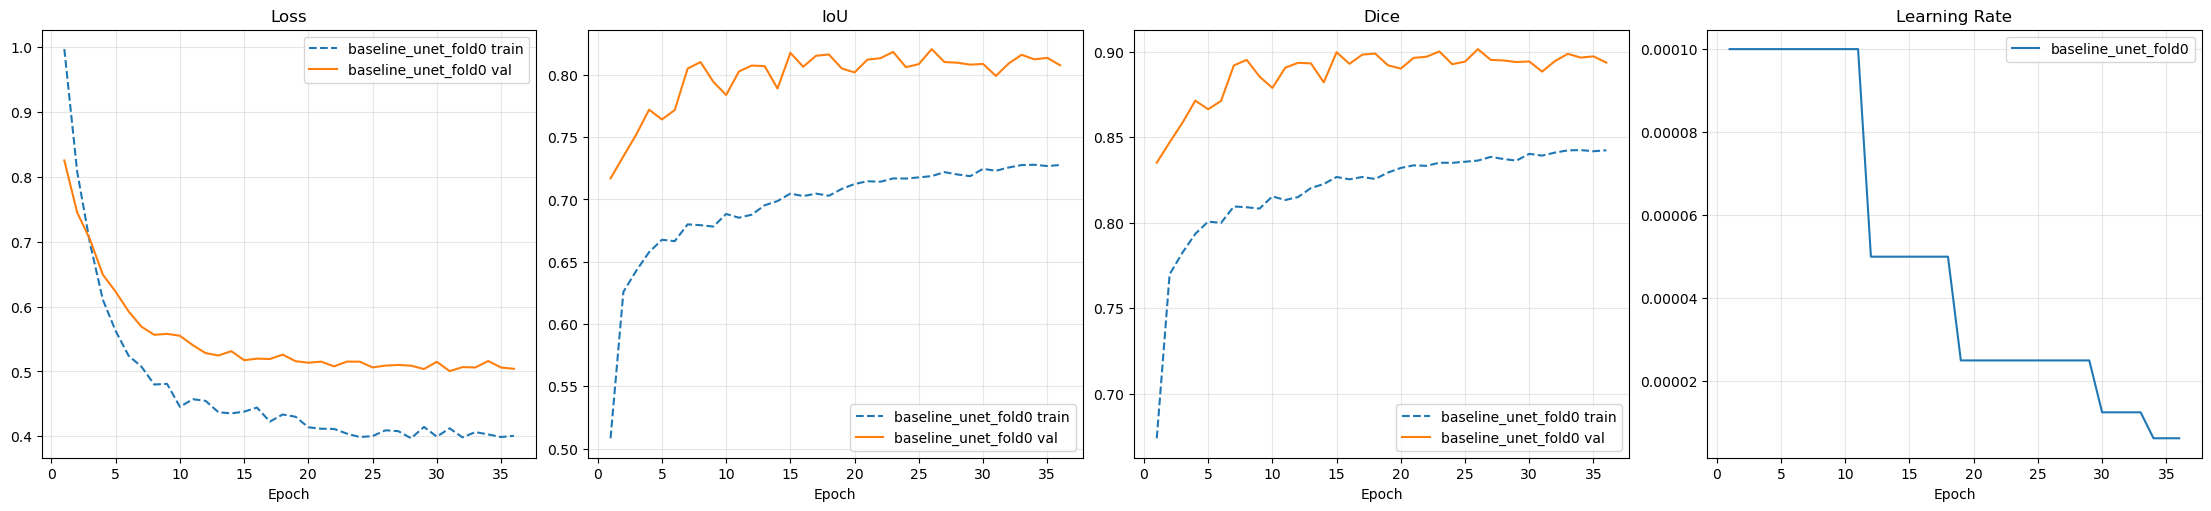

In [7]:
def plot_training_curves(metrics: dict[str, list[dict]]) -> Path:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
    specs = [
        ("loss", "Loss", "train_loss", "val_loss"),
        ("iou", "IoU", "train_iou", "val_iou"),
        ("dice", "Dice", "train_dice", "val_dice"),
    ]
    for ax, (_, title, train_key, val_key) in zip(axes[:3], specs):
        for name, rows in metrics.items():
            epochs = [row["epoch"] for row in rows]
            ax.plot(epochs, [row[train_key] for row in rows], linestyle="--", label=f"{name} train")
            ax.plot(epochs, [row[val_key] for row in rows], label=f"{name} val")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.legend()

    lr_ax = axes[3]
    for name, rows in metrics.items():
        lr_rows = [row for row in rows if row.get("lr") is not None]
        if lr_rows:
            lr_ax.plot([row["epoch"] for row in lr_rows], [row["lr"] for row in lr_rows], label=name)
    lr_ax.set_title("Learning Rate")
    lr_ax.set_xlabel("Epoch")
    lr_ax.grid(True, alpha=0.3)
    lr_ax.legend()

    RUNS_ROOT.mkdir(parents=True, exist_ok=True)
    output_path = RUNS_ROOT / "training_curves.png"
    fig.savefig(output_path, dpi=160)
    return output_path


plot_path = plot_training_curves(metrics)
plot_path


## 8. Cek output wajib

In [8]:
required_outputs = []
for experiment in EXPERIMENTS:
    output_dir = experiment["output_dir"]
    required_outputs.extend([
        output_dir / "best.pt",
        output_dir / "metrics.csv",
        output_dir / "config.json",
    ])
required_outputs.append(RUNS_ROOT / "training_curves.png")

missing = [path for path in required_outputs if not path.exists()]
if missing:
    raise FileNotFoundError("Missing outputs: " + ", ".join(str(path) for path in missing))

for path in required_outputs:
    print(path)

/home/nozomi/Productive/skripsi/runs/unet/fold_0/best.pt
/home/nozomi/Productive/skripsi/runs/unet/fold_0/metrics.csv
/home/nozomi/Productive/skripsi/runs/unet/fold_0/config.json
/home/nozomi/Productive/skripsi/runs/training_curves.png
